In [6]:
from Turbine_Class import Turbine_data
import matplotlib.pyplot as plt

base = '/home/ppxjf3/ONXY_Insight_interview_task/'

Test out Turbine class on Turbine 1 for 2016 data 

In [7]:
#load data
T01_2016 = Turbine_data(base = base,turbine_number='01',year='2016')
print(T01_2016.turbine_data.shape)
colnames = T01_2016.turbine_data.columns.tolist()

# Which faults caused the most downtime?
stops = T01_2016.status_data[T01_2016.status_data['Status'] == 'Stop']
print(stops.groupby('Message')['Duration'].sum().sort_values(ascending=False).head(10))

# What IEC categories dominate?
print(stops.groupby('IEC category')['Duration'].sum().sort_values(ascending=False))


['Wind speed (m/s)', 'Wind speed, Standard deviation (m/s)', 'Wind speed, Minimum (m/s)', 'Wind speed, Maximum (m/s)', 'Long Term Wind (m/s)', 'Wind speed Sensor 1 (m/s)', 'Wind speed Sensor 1, Standard deviation (m/s)', 'Wind speed Sensor 1, Minimum (m/s)', 'Wind speed Sensor 1, Maximum (m/s)', 'Wind speed Sensor 2 (m/s)', 'Wind speed Sensor 2, Standard deviation (m/s)', 'Wind speed Sensor 2, Minimum (m/s)', 'Wind speed Sensor 2, Maximum (m/s)', 'Density adjusted wind speed (m/s)', 'Wind direction (°)', 'Nacelle position (°)', 'Wind direction, Standard deviation (°)', 'Wind direction, Minimum (°)', 'Wind direction, Maximum (°)', 'Nacelle position, Standard deviation (°)', 'Nacelle position, Minimum (°)', 'Nacelle position, Maximum (°)', 'Vane position 1+2 (°)', 'Vane position 1+2, Max (°)', 'Vane position 1+2, Min (°)', 'Vane position 1+2, StdDev (°)', 'Energy Export (kWh)', 'Energy Import (kWh)', 'Lost Production (Contractual) (kWh)', 'Lost Production (Time-based IEC B.2.2) (kWh)', '

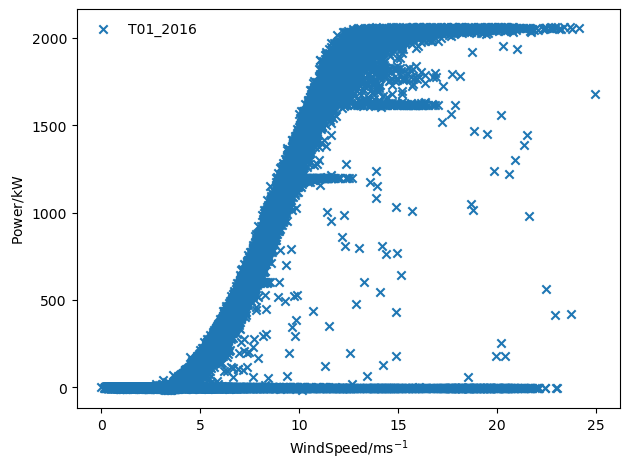

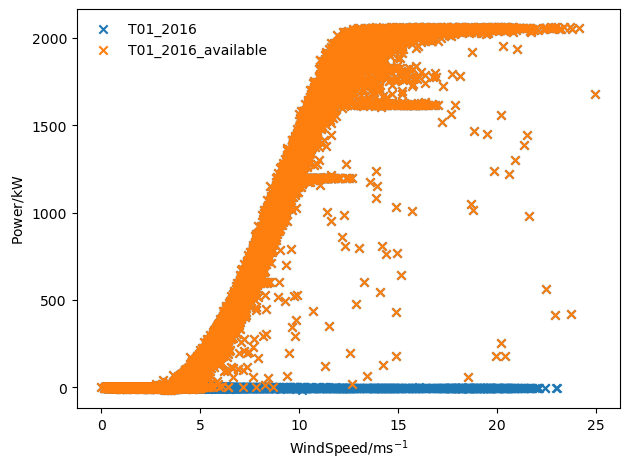

In [8]:
#plot power curve
#strong correlation shows optimal performance
plt.scatter(T01_2016.turbine_data['Wind speed (m/s)'], T01_2016.turbine_data['Power (kW)'], marker='x', label='T01_2016')
plt.xlabel(r'$ \rm Wind Speed /ms^{-1}$')
plt.ylabel(r'$ \rm Power /kW$')
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(base+'plots/initial_power_curve_T01_2016')
plt.show()

#want to have a list of indexes where the turbine is unavalibele i.e. high wind speed and 0kW power
thresh = 5 #ms^-1 (threshold for high wind speed which we would want power > 0kW)
indexes = T01_2016.select_unavailiable_timeperiods(thresh=thresh)

In [9]:
T01_2016.find_downtime_reason(8)

0
Downtime for 71.4 hours on 2016-06-10 13:30:00 due to Check time synchronization 

1
Downtime for 6.2 hours on 2016-06-10 13:30:00 due to Semi-automatic operation 

2
Downtime for 1.0 hours on 2016-06-10 13:30:00 due to Manual yaw 

3
Downtime for 3.1 hours on 2016-06-10 13:30:00 due to Manual stop - on site 



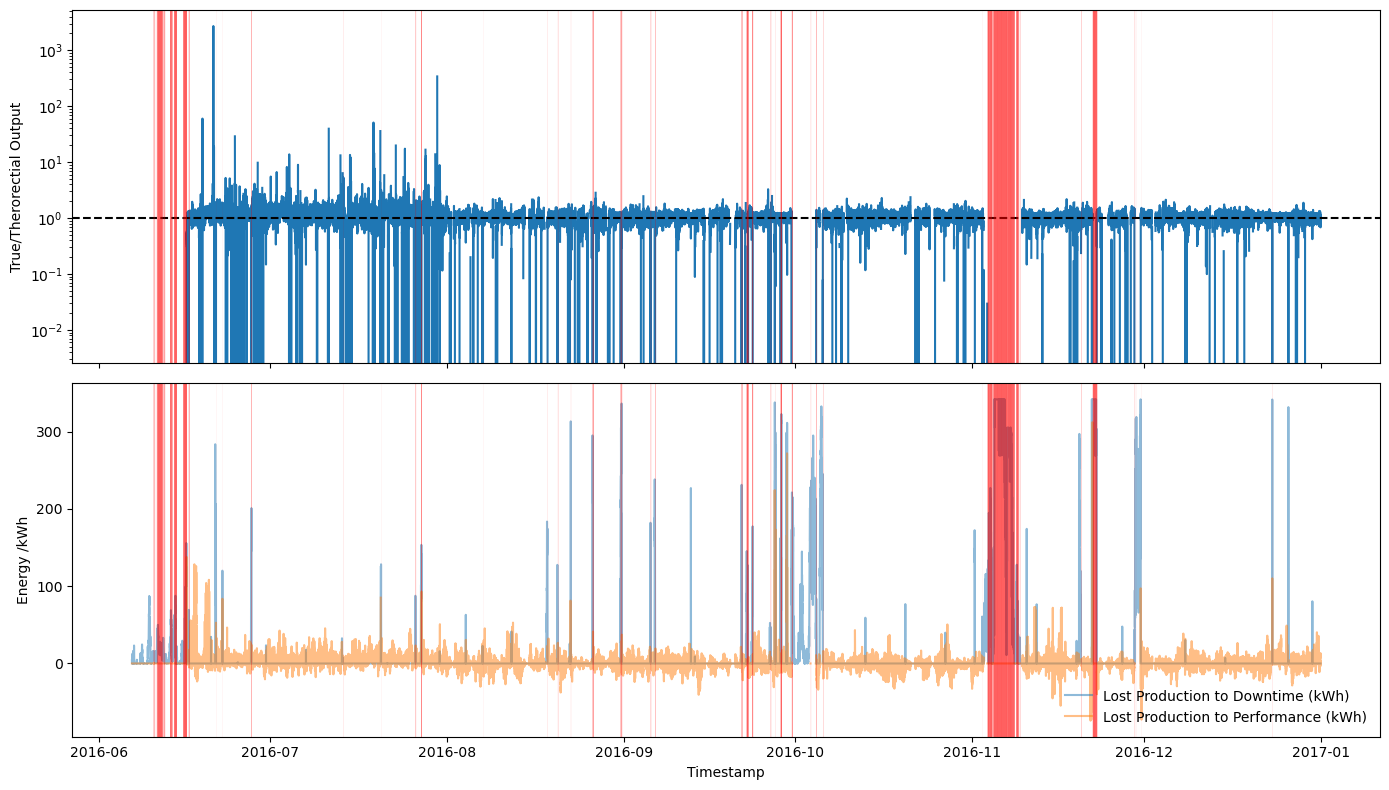

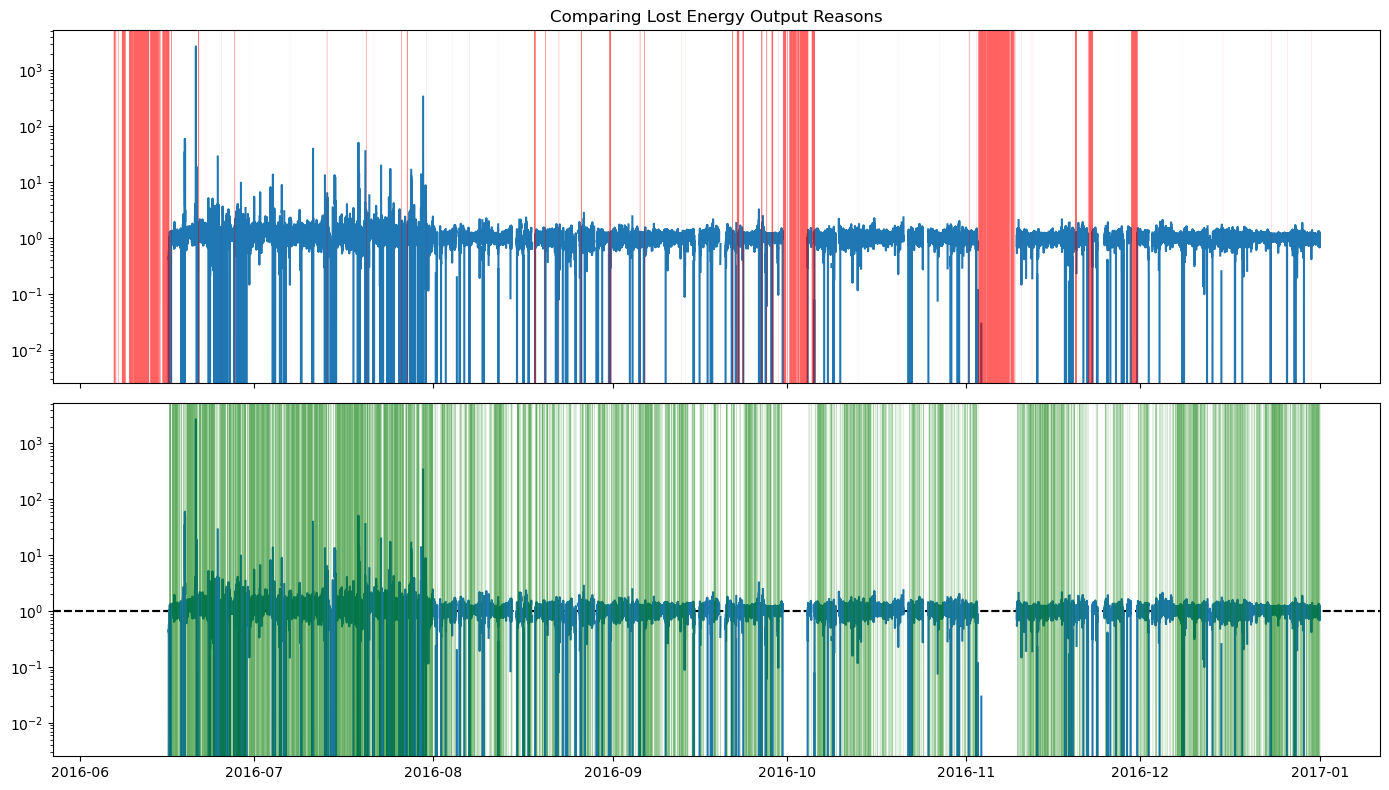

In [10]:
T01_2016.compare_downtime_reasons()

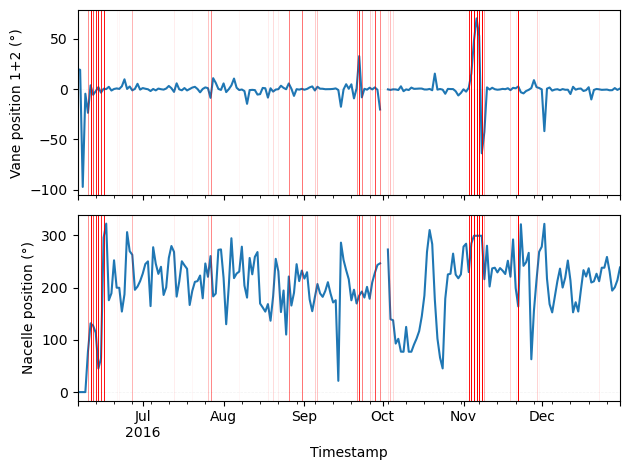

PCC: 0.007, p-value: 0.228


In [11]:
col_names = ['Vane position 1+2 (°)', 'Nacelle position (°)']
opt_values = [0.0, 0.0]
T01_2016.compare_timeseries_data(col_names, opt_values)

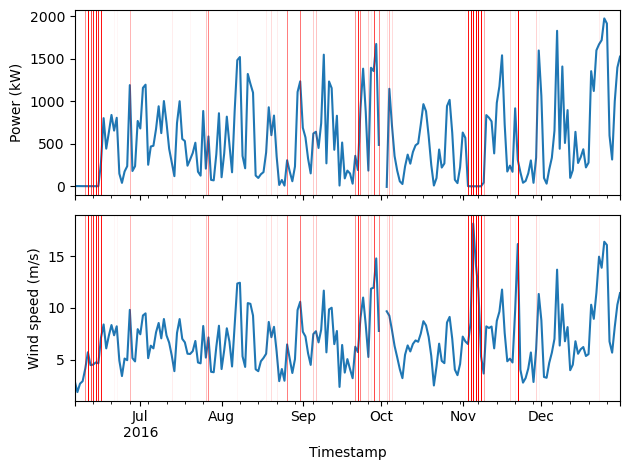

PCC: 0.811, p-value: 0.000


In [12]:
values_to_compare =['Power (kW)', 'Wind speed (m/s)']
T01_2016.compare_timeseries_data(values_to_compare)


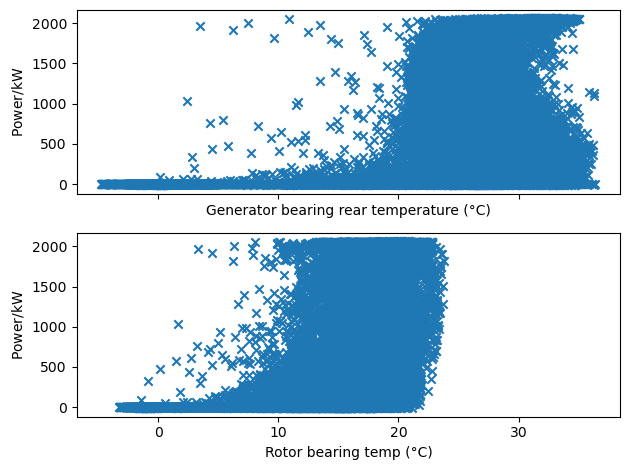

In [13]:
T01_2016.temp_comparison(['Generator bearing rear temperature (°C)', 'Rotor bearing temp (°C)'])

Check if class works for different turbine data

In [14]:
T01_2016 = Turbine_data(base = base,turbine_number='11',year='2016')
print(T01_2016.turbine_data.shape)
colnames = T01_2016.turbine_data.columns.tolist()

# Which faults caused the most downtime?
stops = T01_2016.status_data[T01_2016.status_data['Status'] == 'Stop']
print(stops.groupby('Message')['Duration'].sum().sort_values(ascending=False).head(10))

# What IEC categories dominate?
print(stops.groupby('IEC category')['Duration'].sum().sort_values(ascending=False))

['Wind speed (m/s)', 'Wind speed, Standard deviation (m/s)', 'Wind speed, Minimum (m/s)', 'Wind speed, Maximum (m/s)', 'Long Term Wind (m/s)', 'Wind speed Sensor 1 (m/s)', 'Wind speed Sensor 1, Standard deviation (m/s)', 'Wind speed Sensor 1, Minimum (m/s)', 'Wind speed Sensor 1, Maximum (m/s)', 'Wind speed Sensor 2 (m/s)', 'Wind speed Sensor 2, Standard deviation (m/s)', 'Wind speed Sensor 2, Minimum (m/s)', 'Wind speed Sensor 2, Maximum (m/s)', 'Density adjusted wind speed (m/s)', 'Wind direction (°)', 'Nacelle position (°)', 'Wind direction, Standard deviation (°)', 'Wind direction, Minimum (°)', 'Wind direction, Maximum (°)', 'Nacelle position, Standard deviation (°)', 'Nacelle position, Minimum (°)', 'Nacelle position, Maximum (°)', 'Vane position 1+2 (°)', 'Vane position 1+2, Max (°)', 'Vane position 1+2, Min (°)', 'Vane position 1+2, StdDev (°)', 'Energy Export (kWh)', 'Energy Import (kWh)', 'Lost Production (Contractual) (kWh)', 'Lost Production (Time-based IEC B.2.2) (kWh)', '